In this notebook we plot the data generated by the script 
est_err_homod_diag_iter.py and generate the subplots shown in Fig.2 of the main
text.

In [12]:
import pandas as pd
from qutip import *
from scipy.sparse.linalg import eigs
settings.core = CoreOptions(default_dtype='CSR')
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
import scipy.optimize as opt
rc('text', usetex=True)
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIX"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.borderpad"] = 0.15
mpl.rcParams["font.size"] = 8

In [13]:
def HP_approx(ratio, N, phi):
    """Holstein-Primakoff approximation of the estimation error for homodyne
    detection of the phase phi of the driving field in the boundary time 
    crystal (see Eq. (8) of the main text)."""
    omega_c = N/2
    return 1/(2*ratio*omega_c*abs(np.cos(phi)))

def error_bars(FI, std):
    """Error bars for the estimation error of the phase phi of the driving field
    in the boundary time crystal, obtained from the Fisher information (FI) and
    its standard deviation (std)."""
    return 0.5*std/np.sqrt(FI**3)

    ratio   av_FI_rate       std\t
0     0.2    64.700171    2.929035
1     0.4   255.117328   11.903079
2     0.6   545.007998   25.259432
3     0.8   967.058232   44.572092
4     1.0  2623.713113  119.871371
5     1.2  1846.235269   93.563678
6     1.4   782.762557   36.747104
7     1.6   574.455798   26.185623
8     1.8   499.853989   22.932997
9     2.2   525.022293   24.789548
10    2.6   551.763303   24.789548


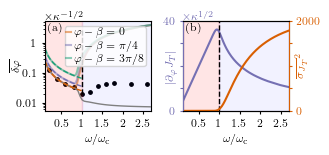

In [14]:
N   = 40 # System size, given by the choice in est_err_homod_diag_iter.py
df  = pd.read_csv(f'est_error_homodyne_N{N}.csv')
df  = pd.DataFrame(df)
df1 = pd.read_csv('FI_rate_param_set_1_N40.dat', sep=';')
df1 = pd.DataFrame(df1)
print(df1)
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()
QFI_dir = os.path.normpath(os.path.join(script_dir, '../Fig-S1'))
df2 = pd.read_csv(os.path.join(QFI_dir, 'QFI_figS1a.csv'))
df2 = pd.DataFrame(df2)

colors=['#1b9e77','#d95f02','#7570b3']

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(0.95*3.54331,0.45*3.54331),
                                     width_ratios=[1,1],
                                     layout='tight')

ax1.plot(df['ratio'].loc[(df['phi']==0) & (df['ratio']<=2.7)], 
         df['est_err_homod'].loc[(df['phi']==0) & (df['ratio']<=2.7)],
         color=colors[1], label=r'$\varphi - \beta=0$', alpha=0.5)
ax1.plot(df['ratio'].loc[(df['phi']==0.25*np.pi) & (df['ratio']<=2.7)], 
         df['est_err_homod'].loc[(df['phi']==0.25*np.pi) & (df['ratio']<=2.7)],
         color=colors[2], label=r'$\varphi - \beta=\pi/4$', alpha=0.5)
ax1.plot(df['ratio'].loc[(df['phi']==0.375*np.pi) & (df['ratio']<=2.7)], 
         df['est_err_homod'].loc[(df['phi']==0.375*np.pi) & (df['ratio']<=2.7)],
         color=colors[0], label=r'$\varphi - \beta=3\pi/8$', alpha=0.5)
ax1.scatter(df1['ratio'], 1/np.sqrt(df1['av_FI_rate']), color='black', s=6, marker='o')
#ax1.errorbar(df1['ratio'], 1/np.sqrt(df1['av_FI_rate']), yerr=10*error_bars(df1['av_FI_rate'], df1['std\t']),
#             fmt='none', ecolor='black', elinewidth=0.5, capsize=2)
ax1.plot(df2['ratio'].loc[(df2['N']==40) & (df2['ratio']<=2.7) & (df2['ratio']>=0.1)], 
         1/np.sqrt(df2['QFI'].loc[(df2['N']==40) & (df2['ratio']<=2.7) & (df2['ratio']>=0.1)]),
           color='gray', linestyle='-', linewidth=1)

ax1.plot(np.linspace(0.1,1,100),
         HP_approx(np.linspace(0.1,1,100), N, 0),
         color=colors[1], linestyle='--', linewidth=1)
ax1.plot(np.linspace(0.1,1,100),
         HP_approx(np.linspace(0.1,1,100), N, 0.25*np.pi),
         color=colors[2], linestyle='--', linewidth=1)
ax1.plot(np.linspace(0.1,1,100),
         HP_approx(np.linspace(0.1,1,100), N, 0.375*np.pi),
         color=colors[0], linestyle='--', linewidth=1)
ax1.set_yscale('log')
ax1.set_xticks([0.5,1,1.5,2,2.5])
ax1.set_xticklabels(['0.5','1','1.5','2','2.5'])
ax1.set_yticks([0.01,0.1,1])
ax1.set_yticklabels(['0.01','0.1','1'])
ax1.set_xlim(0.1,2.7)
ax1.set_ylabel(r'$\overline{\delta\varphi}$')
ax1.set_xlabel(r'$\omega/\omega_\mathrm{c}$')
ax1.vlines(1,0.02,3, colors='black', linestyles='dashed',linewidth=1)
ax1.axvspan(0.1,1,alpha=0.1,color='red')
ax1.axvspan(1,2.7,alpha=0.05,color='blue')
ax1.tick_params(axis='both', which='major', length=2)
ax1.tick_params(axis='both', which='minor', length=1.5)
ax1.yaxis.set_label_coords(-0.22,0.5)
ax1.legend(loc='upper right', handletextpad=0.3, borderpad=0.15, handlelength=0.4, labelspacing=0.2)
ax1.text(0.03,0.98, '(a)', transform=ax1.transAxes, verticalalignment='top', horizontalalignment='left')
ax1.text(0,1,r'$\times\kappa^{-1/2}$', transform=ax1.transAxes, va='bottom', ha='left')

ax3 = ax2.twinx()
ax3.plot(df['ratio'].loc[(df['phi']==0) & (df['ratio']<=2.7)],
         df['std'].loc[(df['phi']==0) & (df['ratio']<=2.7)]**2,
         color=colors[1])
ax2.plot(df['ratio'].loc[(df['phi']==0) & (df['ratio']<=2.7)],
         df['abs_deriv'].loc[(df['phi']==0) & (df['ratio']<=2.7)],
         color=colors[2])
ax3.set_xlim(0,2.7)
ax3.set_xticks([0.5,1,1.5,2,2.5])
ax3.set_xticklabels(['0.5','1','1.5','2','2.5'])
ax3.set_yticks([0, 500, 1000, 1500, 2000])
ax3.set_yticklabels(['0','','','','2000'])
ax2.set_yticks([0,10,20,30,40])
ax2.set_yticklabels(['0','','','','40'])
ax3.set_ylim(0,2000)
ax2.set_ylim(0,40)
ax2.set_xlim(0.1,2.7)
ax3.set_xlim(0.1,2.7)
ax2.set_xlabel(r'$\omega/\omega_\mathrm{c}$')
ax3.set_ylabel(r'$\overline{\sigma_{J_T}}^2$',color=colors[1])
ax2.set_ylabel(r'$|\partial_\varphi J_T|$',color=colors[2])
ax3.spines['left'].set_color(colors[2])
ax2.tick_params(axis='y', colors=colors[2], which='both')
ax3.spines['right'].set_color(colors[1])
ax3.tick_params(axis='y', colors=colors[1], which='both')
ax2.vlines(1,0,40, colors='black', linestyles='dashed',linewidth=1)
ax2.axvspan(0.1,1,alpha=0.1,color='red')
ax2.axvspan(1,2.7,alpha=0.05,color='blue')
ax2.tick_params(axis='both', which='major', length=2)
ax3.tick_params(axis='both', which='major', length=2)
ax2.yaxis.set_label_coords(-0.05,0.5)
ax3.yaxis.set_label_coords(1.05,0.5)
ax2.text(0.03, 0.98, '(b)', transform=ax2.transAxes, verticalalignment='top', horizontalalignment='left')
ax2.text(0,1,r'$\times\kappa^{1/2}$', color=colors[2], transform=ax2.transAxes, va='bottom', ha='left')

plt.show()
fig.savefig('est_err_homodyne.pdf',dpi=1000)